<a href="https://colab.research.google.com/github/avram4uk/6praktika/blob/main/%D0%B3%D0%BB%D0%B0%D0%B2%D0%B0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import pandas as pd
from pathlib import Path

# Укажите путь к корневой папке датасета после распаковки
DATASET_PATH = Path("/content/датасет")

def analyze_dataset_structure(dataset_path):
    """
    Анализирует структуру датасета, выводя общее количество изображений,
    список классов и количество элементов в каждом классе.
    """
    print("=" * 60)
    print("АНАЛИЗ ДАТАСЕТА: Gender Detection & Classification")
    print("=" * 60)

    # Словарь для хранения количества изображений по классам
    class_counts = {"women": 0, "men": 0}
    total_images = 0

    # Рекурсивный обход всех подпапок
    for root, dirs, files in os.walk(dataset_path):
        # Проверяем, находится ли текущая папка внутри папки класса
        # Папки классов могут быть: 'women', 'men' (игнорируем регистр)
        current_folder = os.path.basename(root).lower()

        if current_folder in class_counts:
            # Считаем только файлы изображений (распространённые расширения)
            image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
            image_files = [
                f for f in files
                if Path(f).suffix.lower() in image_extensions
            ]
            count = len(image_files)
            class_counts[current_folder] += count
            total_images += count

            # Выводим информацию по каждой найденной папке
            rel_path = os.path.relpath(root, dataset_path)
            if rel_path == '.':
                rel_path = current_folder
            print(f"📁 Папка: {rel_path} -> {count} изображений")

    print("\n" + "=" * 60)
    print("ИТОГОВАЯ СТАТИСТИКА")
    print("=" * 60)
    print(f"📊 Общее количество изображений в датасете: {total_images}")
    print(f"\n🏷️  Классы и количество элементов:")
    for class_name, count in class_counts.items():
        print(f"   - {class_name.capitalize()} ({class_name}): {count} изображений")

    # Дополнительно: анализ через CSV-файл (если он существует)
    csv_path = dataset_path / "gender_detection.csv"
    if csv_path.exists():
        print("\n" + "-" * 60)
        print("ПРОВЕРКА ПО CSV-ФАЙЛУ")
        print("-" * 60)
        df = pd.read_csv(csv_path)

        # Проверяем наличие колонки с метками пола
        if 'gender' in df.columns:
            csv_counts = df['gender'].value_counts()
            print("Статистика из CSV-файла:")
            for gender, count in csv_counts.items():
                print(f"   - {gender}: {count} записей")

    return class_counts, total_images

class_counts, total = analyze_dataset_structure(DATASET_PATH)

АНАЛИЗ ДАТАСЕТА: Gender Detection & Classification
📁 Папка: test/men -> 40 изображений
📁 Папка: test/women -> 40 изображений
📁 Папка: train/men -> 110 изображений
📁 Папка: train/women -> 110 изображений

ИТОГОВАЯ СТАТИСТИКА
📊 Общее количество изображений в датасете: 300

🏷️  Классы и количество элементов:
   - Women (women): 150 изображений
   - Men (men): 150 изображений

------------------------------------------------------------
ПРОВЕРКА ПО CSV-ФАЙЛУ
------------------------------------------------------------
Статистика из CSV-файла:
   - woman: 150 записей
   - man: 150 записей


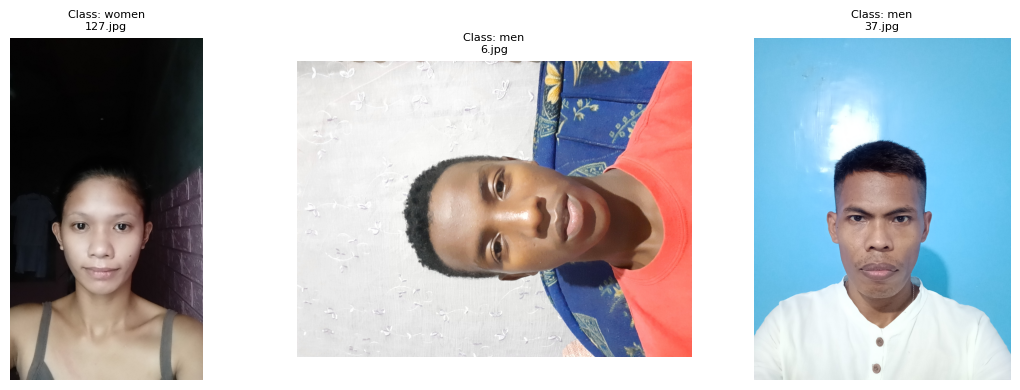

Всего изображений: 300
1. /content/датасет/test/women/127.jpg (Class: women)
2. /content/датасет/train/men/6.jpg (Class: men)
3. /content/датасет/train/men/37.jpg (Class: men)


In [10]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Собираем все изображения
images = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
    images.extend(DATASET_PATH.rglob(ext))

# Выбираем 3 случайных изображения
selected = random.sample(images, min(3, len(images)))

# Отображаем
fig, axes = plt.subplots(1, len(selected), figsize=(12, 4))
for i, img_path in enumerate(selected):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Class: {img_path.parent.name}\n{img_path.name}", fontsize=8)

plt.tight_layout()
plt.show()

# Выводим информацию
print(f"Всего изображений: {len(images)}")
for i, img_path in enumerate(selected, 1):
    print(f"{i}. {img_path} (Class: {img_path.parent.name})")